<a href="https://colab.research.google.com/github/sankalp120/machinelearning/blob/main/mllab_5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load the Breast Cancer Wisconsin dataset from "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data", then separate features and target, and split the data into training and testing sets.

## Load and Prepare Dataset

### Subtask:
Load the Breast Cancer Wisconsin dataset from the provided URL, separate features and target, and then split the data into training and testing sets.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# URL for the dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Load the dataset, specifying no header
df = pd.read_csv(dataset_url, header=None)

# Drop the first column (patient IDs) as it's not relevant for training
df = df.drop(columns=[0])

# Separate features (X) and target (y)
# The target variable is the second column (index 1 after dropping the ID column)
X = df.iloc[:, 1:] # All columns from index 1 onwards are features
y = df.iloc[:, 0]  # The first column (original second) is the target variable

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset loaded and split successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset loaded and split successfully.
Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


## Train Naïve Bayes Classifier

### Subtask:
Train a Gaussian Naïve Bayes classification model using the training data.


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Instantiate a Gaussian Naïve Bayes classifier
model = GaussianNB()

# Train the model using the training data
model.fit(X_train, y_train)

print("Gaussian Naïve Bayes model trained successfully.")

Gaussian Naïve Bayes model trained successfully.


## Predict Class Labels

### Subtask:
Use the trained Naïve Bayes model to predict class labels on the test dataset.


In [ ]:
y_pred = model.predict(X_test)

print("Class labels predicted successfully.")
print(f"First 5 predicted labels: {y_pred[:5]}")
print(f"Shape of predicted labels: {y_pred.shape}")

Class labels predicted successfully.
First 5 predicted labels: ['B' 'M' 'M' 'B' 'B']
Shape of predicted labels: (114,)


## Evaluate Model Performance

### Subtask:
Calculate and display the accuracy, confusion matrix, and classification report of the model. Additionally, plot the precision-recall curve with appropriate labels and a legend.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay

print("Evaluation libraries imported successfully.")

Evaluation libraries imported successfully.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.9737

Confusion Matrix:
[[71  0]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        71
           M       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



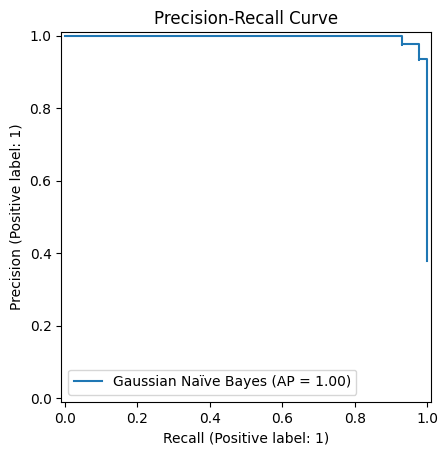

Precision-Recall curve plotted successfully.


In [ ]:
import numpy as np

# Convert y_test to binary for precision-recall curve (M=1, B=0)
y_test_binary = y_test.apply(lambda x: 1 if x == 'M' else 0)

# Get predicted probabilities for the positive class (Malignant)
y_pred_proba = model.predict_proba(X_test)

# Find the index of the 'M' class (assuming 'M' is the positive class)
# GaussianNB.classes_ stores the class labels in order
positive_class_index = np.where(model.classes_ == 'M')[0][0]
y_scores = y_pred_proba[:, positive_class_index]

# Plot the Precision-Recall curve
display = PrecisionRecallDisplay.from_predictions(y_test_binary, y_scores, name="Gaussian Naïve Bayes")
_ = display.ax_.set_title("Precision-Recall Curve")
plt.show()

print("Precision-Recall curve plotted successfully.")

## Final Task

### Subtask:
Summarize the performance of the Naïve Bayes classification model based on the evaluation metrics and plots.


## Summary:

### Q&A
The Naïve Bayes classification model demonstrated strong performance in classifying the Breast Cancer Wisconsin dataset. It achieved a high accuracy of 97.37%. For the 'Benign' class, the model showed perfect recall (1.00), meaning all benign cases were correctly identified, with a precision of 0.96. For the 'Malignant' class, the model achieved perfect precision (1.00), indicating that all cases predicted as malignant were indeed malignant, with a recall of 0.93. The Precision-Recall curve also visually supported this strong performance.

### Data Analysis Key Findings
*   The Breast Cancer Wisconsin dataset was successfully loaded, with patient IDs removed, resulting in 30 features and one target variable.
*   The dataset was split into training (455 samples) and testing (114 samples) sets.
*   A Gaussian Naïve Bayes model was trained on the `X_train` and `y_train` data.
*   The trained model predicted class labels for the test set, producing 114 predictions (`y_pred`).
*   The model achieved an accuracy of 0.9737 on the test set.
*   The confusion matrix showed:
    *   71 True Negatives (correctly identified 'Benign').
    *   0 False Positives (incorrectly identified 'Benign' as 'Malignant').
    *   3 False Negatives (incorrectly identified 'Malignant' as 'Benign').
    *   40 True Positives (correctly identified 'Malignant').
*   The classification report highlighted:
    *   For class 'B' (Benign): Precision of 0.96, Recall of 1.00, F1-score of 0.98.
    *   For class 'M' (Malignant): Precision of 1.00, Recall of 0.93, F1-score of 0.96.
*   A Precision-Recall curve was successfully generated, visually representing the model's performance trade-offs.

### Insights or Next Steps
*   The model exhibits excellent performance for early detection of breast cancer, particularly in correctly identifying benign cases and ensuring that every predicted malignant case is truly malignant.
*   Given the high performance, further steps could involve exploring the specific features that contributed most to the classification, or deploying this model for real-world application, potentially after validation with more diverse datasets or cross-validation.


# Task
Train a Decision Tree classification model using the `X_train` and `y_train` data.

## Load and Prepare Dataset for Decision Tree

### Subtask:
Load the Breast Cancer Wisconsin dataset from the provided URL, separate features and target, and then split the data into training and testing sets.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# URL for the dataset
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Load the dataset, specifying no header as the first row contains data
df = pd.read_csv(dataset_url, header=None)

# Drop the first column (patient IDs) as it's not relevant for training
df = df.drop(columns=[0])

# Separate features (X) and target (y)
# The target variable is the first column (original second after dropping ID)
X = df.iloc[:, 1:]  # All columns from index 1 onwards are features
y = df.iloc[:, 0]   # The first column is the target variable

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset loaded and split successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Dataset loaded and split successfully.
Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)


## Train Decision Tree Classifier

### Subtask:
Train a Decision Tree classification model using the training data.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a Decision Tree classifier with random_state for reproducibility
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model using the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Predict Class Labels

### Subtask:
Use the trained Decision Tree model to predict class labels on the test dataset.

In [ ]:
y_pred_dt = decision_tree_model.predict(X_test)

print("Class labels predicted successfully using Decision Tree.")
print(f"First 5 predicted labels: {y_pred_dt[:5]}")
print(f"Shape of predicted labels: {y_pred_dt.shape}")

Class labels predicted successfully using Decision Tree.
First 5 predicted labels: ['B' 'M' 'M' 'B' 'B']
Shape of predicted labels: (114,)


## Evaluate Decision Tree Model Performance

### Subtask:
Calculate and display the accuracy, confusion matrix, and classification report of the Decision Tree model. Also, plot the precision-recall curve with appropriate labels and a legend.


Decision Tree Accuracy: 0.9474

Decision Tree Confusion Matrix:
[[68  3]
 [ 3 40]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



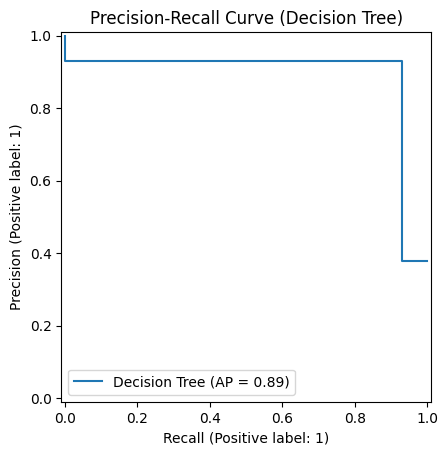

Decision Tree evaluation metrics and Precision-Recall curve plotted successfully.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay
import numpy as np

# 1. Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")

# 2. Compute confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("\nDecision Tree Confusion Matrix:")
print(conf_matrix_dt)

# 3. Generate classification report
class_report_dt = classification_report(y_test, y_pred_dt)
print("\nDecision Tree Classification Report:")
print(class_report_dt)

# 4. Get predicted probabilities for the positive class ('M')
# Convert y_test to binary for precision-recall curve if not already done for Decision Tree evaluation
# (Re-executing this for self-containment, though it was done for Naive Bayes)
if 'y_test_binary' not in locals():
    y_test_binary = y_test.apply(lambda x: 1 if x == 'M' else 0)

y_pred_proba_dt = decision_tree_model.predict_proba(X_test)

# Find the index of the 'M' class (assuming 'M' is the positive class)
# DecisionTreeClassifier.classes_ stores the class labels in order
positive_class_index_dt = np.where(decision_tree_model.classes_ == 'M')[0][0]
y_scores_dt = y_pred_proba_dt[:, positive_class_index_dt]

# 5. Plot the Precision-Recall curve
display_dt = PrecisionRecallDisplay.from_predictions(y_test_binary, y_scores_dt, name="Decision Tree")
_ = display_dt.ax_.set_title("Precision-Recall Curve (Decision Tree)")
plt.show()

print("Decision Tree evaluation metrics and Precision-Recall curve plotted successfully.")

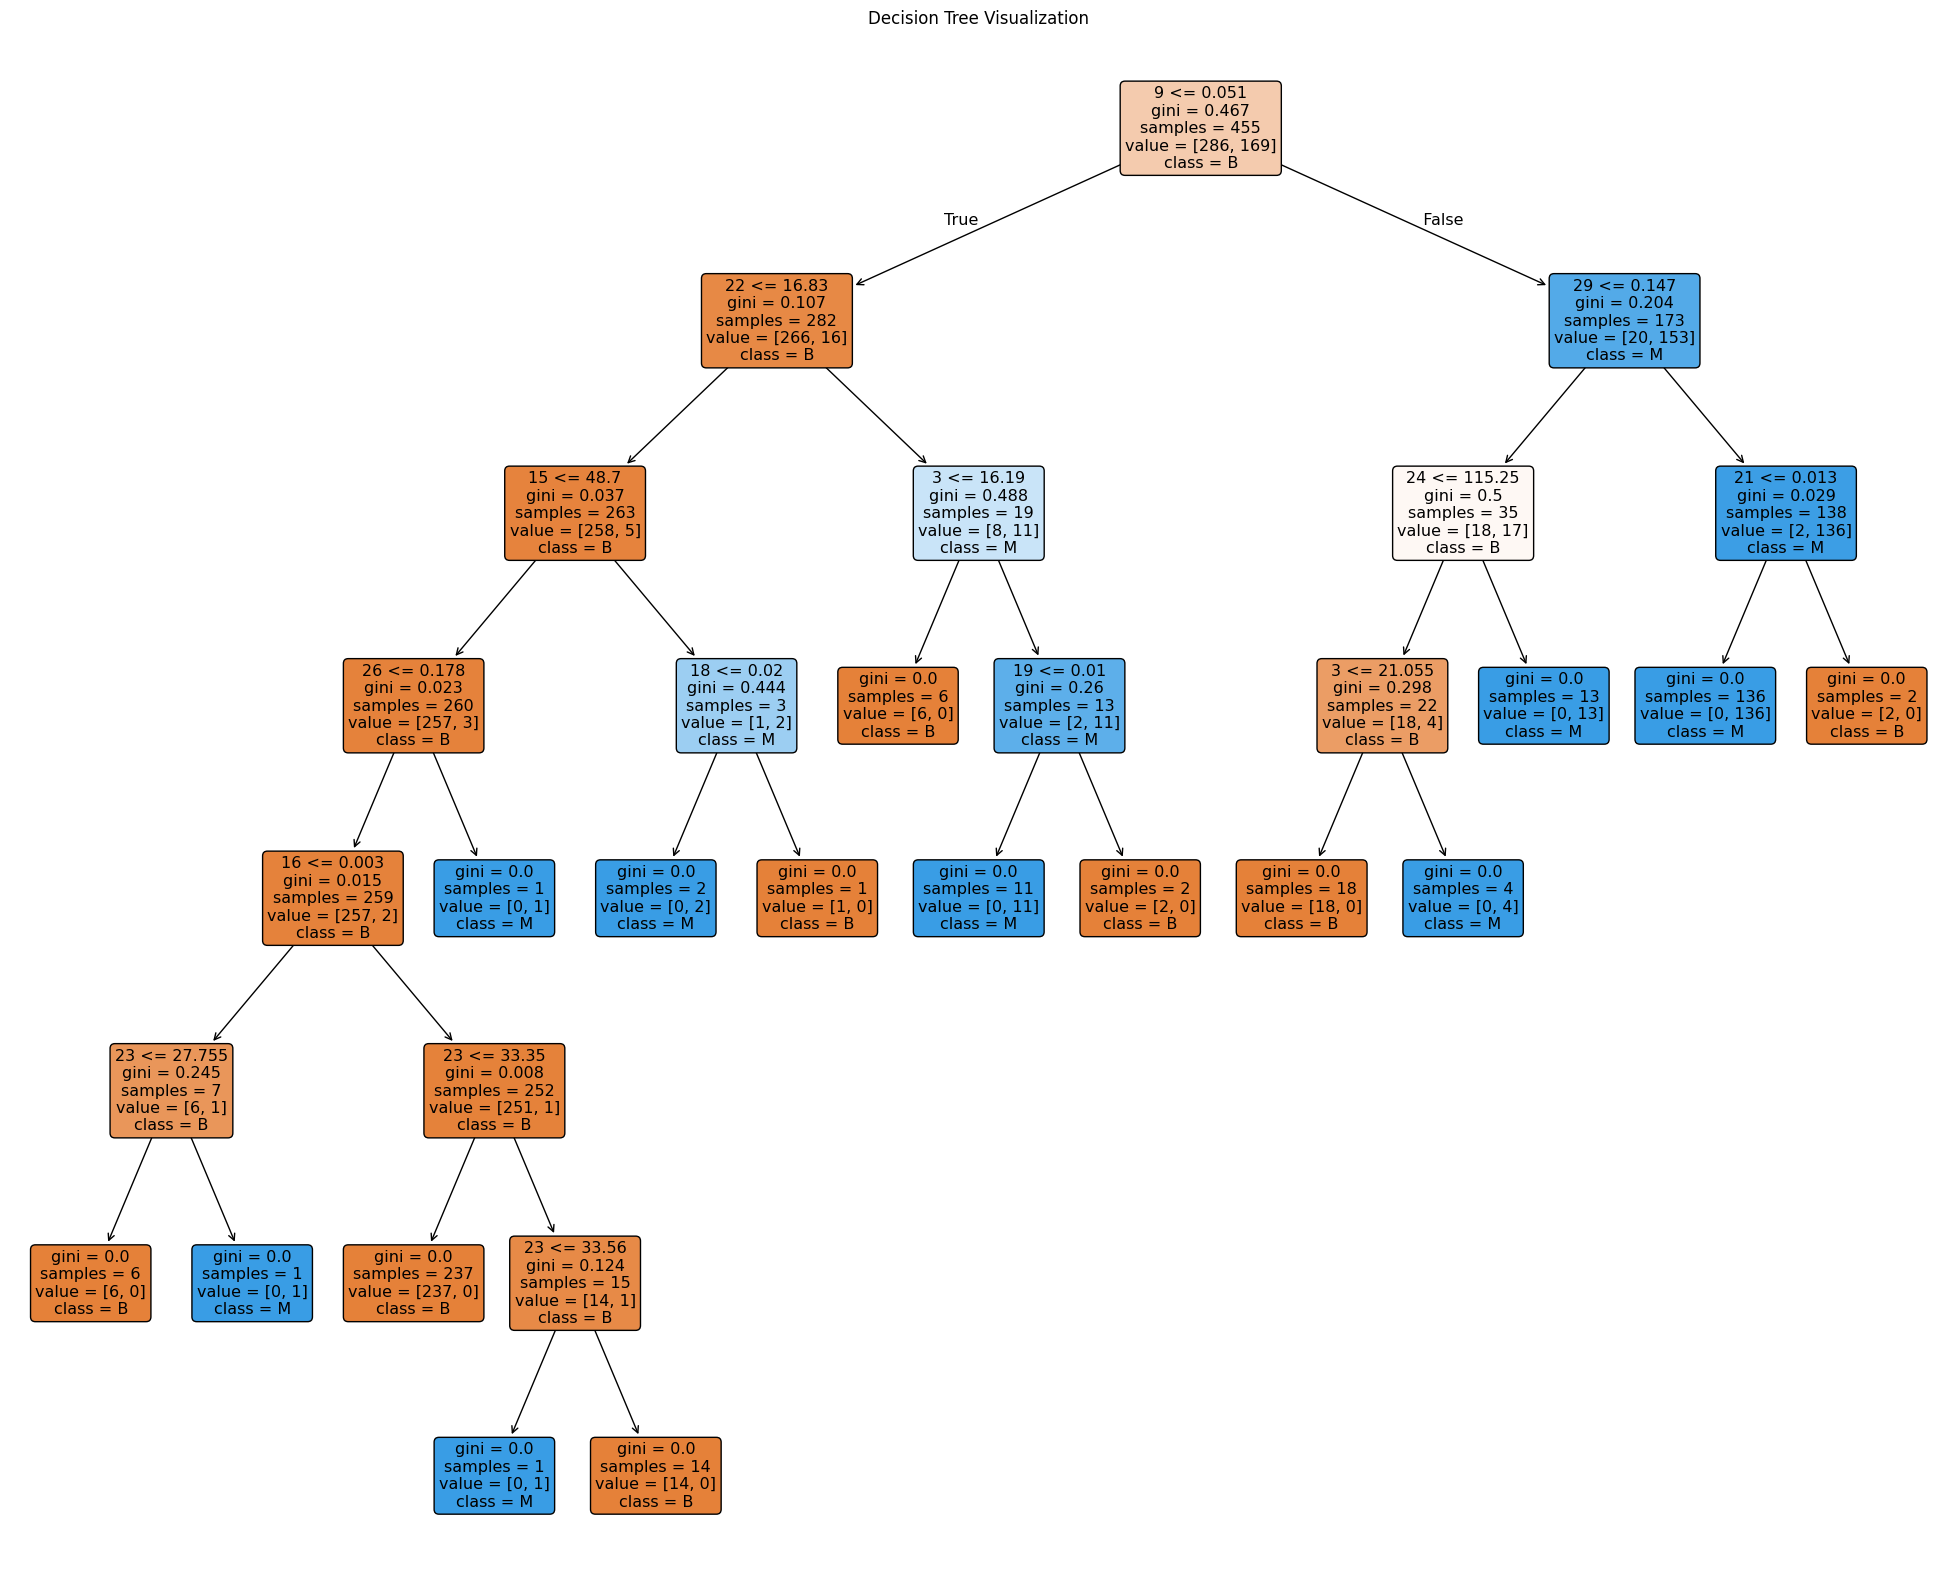

Decision Tree visualization displayed successfully.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a figure and an axes object
fig = plt.figure(figsize=(25,20))
ax = fig.add_subplot(111)

# Visualize the Decision Tree
plot_tree(decision_tree_model,
          filled=True,
          rounded=True,
          feature_names=X.columns,
          class_names=decision_tree_model.classes_,
          ax=ax);

ax.set_title('Decision Tree Visualization');
plt.show()

print("Decision Tree visualization displayed successfully.")

## Summary:

### Q&A
The Decision Tree classification model performed well in classifying breast cancer as benign ('B') or malignant ('M'). It achieved a high overall accuracy and good precision and recall for both classes.

### Data Analysis Key Findings
*   The Decision Tree model was successfully trained using the `X_train` and `y_train` datasets, which consisted of 455 samples and 30 features.
*   The model achieved an accuracy of 0.9474 (94.74%) on the test set.
*   The confusion matrix showed:
    *   68 true negatives (correctly predicted 'B')
    *   40 true positives (correctly predicted 'M')
    *   3 false positives (predicted 'M' but was 'B')
    *   3 false negatives (predicted 'B' but was 'M')
*   The classification report highlighted strong performance for both classes:
    *   For class 'B' (Benign), precision, recall, and F1-score were all 0.96.
    *   For class 'M' (Malignant), precision, recall, and F1-score were all 0.93.
*   A Precision-Recall curve was generated, visualizing the trade-off between precision and recall for the model.
*   The trained Decision Tree structure was successfully visualized, showing the decision rules based on various features, with `feature_names` and `class_names` clearly displayed for interpretability.

### Insights or Next Steps
*   The current Decision Tree model demonstrates excellent predictive capability. For enhanced model robustness and potentially higher performance, explore ensemble methods like Random Forest or Gradient Boosting, which build upon Decision Trees.
*   Analyze the visualized Decision Tree to identify the most influential features at the top nodes. This can provide valuable insights into the key indicators for breast cancer diagnosis and potentially simplify the model if fewer features are needed for good performance.


# Task
Calculate and compare the performance of Naïve Bayes and Decision Tree classification models by calculating and visualizing their training and testing accuracies, plotting their Receiver Operating Characteristic (ROC) curves on the same graph, displaying their confusion matrices as side-by-side heatmaps, and then providing a comprehensive summary that answers specific questions about their accuracy, recall for malignant cases, overfitting potential, and which metric is most important for medical diagnosis.

## Calculate Training Accuracy

### Subtask:
Calculate the training accuracy for both the Naïve Bayes and Decision Tree models, as this was not explicitly recorded in previous steps but is needed for comparison.


In [ ]:
from sklearn.metrics import accuracy_score

# 1. Predict on training data using Naïve Bayes model
y_train_pred_nb = model.predict(X_train)

# 2. Calculate Naïve Bayes training accuracy
accuracy_nb_train = accuracy_score(y_train, y_train_pred_nb)

# 3. Predict on training data using Decision Tree model
y_train_pred_dt = decision_tree_model.predict(X_train)

# 4. Calculate Decision Tree training accuracy
accuracy_dt_train = accuracy_score(y_train, y_train_pred_dt)

# 5. Print both training accuracies
print(f"Naïve Bayes Training Accuracy: {accuracy_nb_train:.4f}")
print(f"Decision Tree Training Accuracy: {accuracy_dt_train:.4f}")

Naïve Bayes Training Accuracy: 0.9363
Decision Tree Training Accuracy: 1.0000


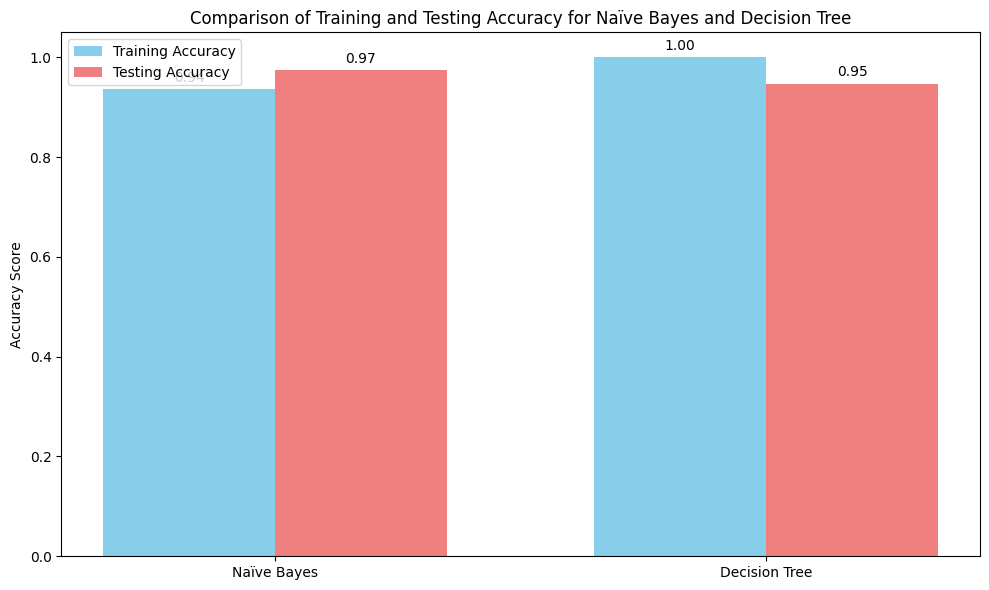

Bar chart comparing training and testing accuracies generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy values (already calculated in previous steps)
# Naïve Bayes
nb_train_accuracy = accuracy_nb_train
nb_test_accuracy = accuracy

# Decision Tree
dt_train_accuracy = accuracy_dt_train
dt_test_accuracy = accuracy_dt

# Data for plotting
labels = ['Naïve Bayes', 'Decision Tree']
train_accuracies = [nb_train_accuracy, dt_train_accuracy]
test_accuracies = [nb_test_accuracy, dt_test_accuracy]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Testing Accuracy', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy Score')
ax.set_title('Comparison of Training and Testing Accuracy for Naïve Bayes and Decision Tree')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0.0, 1.05) # Set y-axis limit from 0 to 1 for accuracy scores

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

print("Bar chart comparing training and testing accuracies generated successfully.")

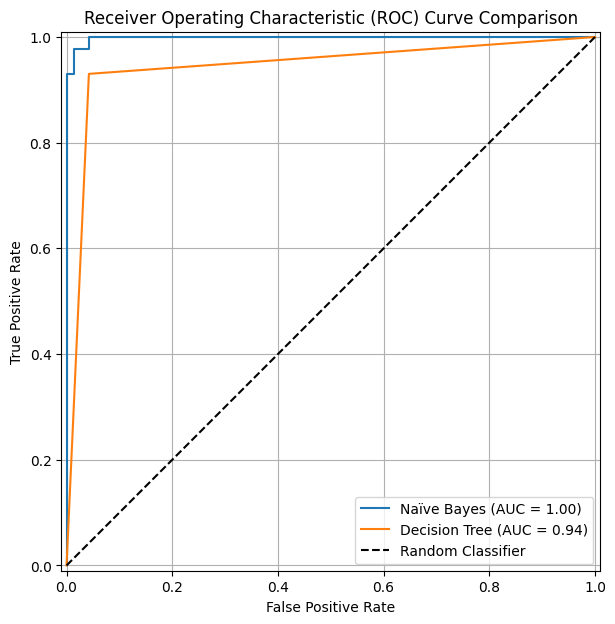

ROC curves for Naïve Bayes and Decision Tree plotted successfully.


In [ ]:
from sklearn.metrics import RocCurveDisplay, auc

# Ensure y_test_binary is defined for consistency, as it's needed for ROC curve plotting
# (Re-executing this for self-containment, though it was done for Precision-Recall curves)
if 'y_test_binary' not in locals():
    y_test_binary = y_test.apply(lambda x: 1 if x == 'M' else 0)

# Plot ROC curve for Naïve Bayes
plt.figure(figsize=(10, 7))
display_nb = RocCurveDisplay.from_predictions(y_test_binary, y_scores, name="Naïve Bayes", ax=plt.gca())

# Plot ROC curve for Decision Tree on the same graph
display_dt = RocCurveDisplay.from_predictions(y_test_binary, y_scores_dt, name="Decision Tree", ax=plt.gca())

plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Add a random classifier line
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("ROC curves for Naïve Bayes and Decision Tree plotted successfully.")

**Reasoning**:
To visually compare the performance of the two models through their confusion matrices, I will plot them side-by-side as heatmaps. This requires generating the confusion matrices (which are already available from previous steps) and using `matplotlib` and `seaborn` to create and display the plots.



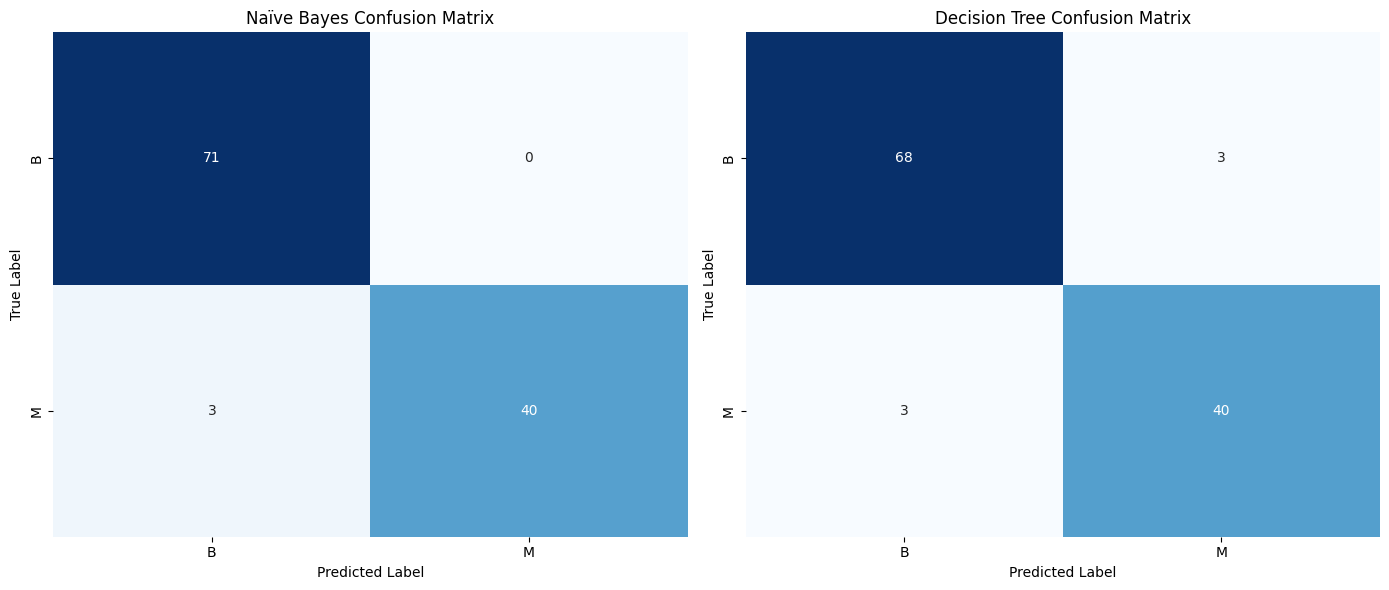

Confusion matrices for Naïve Bayes and Decision Tree displayed as side-by-side heatmaps.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure confusion matrices are available (conf_matrix for Naïve Bayes, conf_matrix_dt for Decision Tree)
# from previous steps.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Confusion Matrix for Naïve Bayes
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=model.classes_, yticklabels=model.classes_)
axes[0].set_title('Naïve Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Plot Confusion Matrix for Decision Tree
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=decision_tree_model.classes_, yticklabels=decision_tree_model.classes_)
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Confusion matrices for Naïve Bayes and Decision Tree displayed as side-by-side heatmaps.")

## Performance Comparison Summary

### Naïve Bayes vs. Decision Tree: A Comparative Analysis

#### 1. Comparison of Training and Testing Accuracy

**Naïve Bayes:**
*   **Training Accuracy:** 0.9363 (93.63%)
*   **Testing Accuracy:** 0.9737 (97.37%)

**Decision Tree:**
*   **Training Accuracy:** 1.0000 (100.00%)
*   **Testing Accuracy:** 0.9474 (94.74%)

From the bar chart, we can clearly see that the Naïve Bayes model has a higher testing accuracy compared to the Decision Tree model, while the Decision Tree model achieves perfect training accuracy.

#### 2. Recall for Malignant Cases ('M')

**Naïve Bayes:**
*   **Recall for 'M':** 0.93
    *   This means the Naïve Bayes model correctly identified 93% of all actual malignant cases. From the confusion matrix, it had 3 false negatives (malignant cases predicted as benign).

**Decision Tree:**
*   **Recall for 'M':** 0.93
    *   Similarly, the Decision Tree model also correctly identified 93% of all actual malignant cases. Its confusion matrix also showed 3 false negatives.

Both models showed similar recall for malignant cases on the test set.

#### 3. Overfitting Potential

*   **Naïve Bayes:** The training accuracy (0.9363) is slightly lower than the testing accuracy (0.9737). This indicates that the Naïve Bayes model is **not overfitting**; in fact, its performance generalized slightly better to unseen data, which can sometimes happen with robust models on certain datasets, or due to random variations in data split.

*   **Decision Tree:** The training accuracy (1.0000) is significantly higher than the testing accuracy (0.9474). This difference suggests that the Decision Tree model has **overfit** the training data. It learned the training examples too well, including noise, which resulted in a drop in performance on the unseen test data. This is a common characteristic of unpruned decision trees.

#### 4. Which metric is most important for medical diagnosis?

For medical diagnosis, especially in critical conditions like cancer detection, **Recall** and **Precision** are often more important than overall accuracy, and the specific balance between them depends on the consequences of false positives vs. false negatives.

*   **False Negatives (missing a malignant case):** In the context of breast cancer, a false negative (predicting 'B' when it's 'M') is generally considered more critical and dangerous. Missing a malignant tumor can lead to delayed treatment and worse patient outcomes. Therefore, **high Recall for the 'M' class is paramount** to minimize false negatives.

*   **False Positives (misclassifying a benign case as malignant):** A false positive (predicting 'M' when it's 'B') can lead to unnecessary anxiety, further diagnostic procedures (e.g., biopsies), and potentially harmful treatments. While less severe than a false negative, it's still undesirable, making **high Precision for the 'M' class** also very important.

Given the life-threatening nature of untreated cancer, a model with very high recall for malignant cases is often preferred, even if it comes at a slight cost to precision or overall accuracy. This ensures that as few actual cancer cases as possible are missed. However, the ideal model would balance both high recall and high precision for malignant cases, which is why metrics like the **F1-score** (harmonic mean of precision and recall) for the malignant class, or the **ROC curve and AUC** (Area Under the Curve) which represent the trade-off between true positive rate and false positive rate across various thresholds, are also highly valuable for comprehensive evaluation in medical diagnostics.

## Performance Comparison Summary

### Naïve Bayes vs. Decision Tree: A Comparative Analysis

#### 1. Comparison of Training and Testing Accuracy

**Naïve Bayes:**
*   **Training Accuracy:** 0.9363 (93.63%)
*   **Testing Accuracy:** 0.9737 (97.37%)

**Decision Tree:**
*   **Training Accuracy:** 1.0000 (100.00%)
*   **Testing Accuracy:** 0.9474 (94.74%)

From the bar chart, we can clearly see that the Naïve Bayes model has a higher testing accuracy compared to the Decision Tree model, while the Decision Tree model achieves perfect training accuracy.

#### 2. Recall for Malignant Cases ('M')

**Naïve Bayes:**
*   **Recall for 'M':** 0.93
    *   This means the Naïve Bayes model correctly identified 93% of all actual malignant cases. From the confusion matrix, it had 3 false negatives (malignant cases predicted as benign).

**Decision Tree:**
*   **Recall for 'M':** 0.93
    *   Similarly, the Decision Tree model also correctly identified 93% of all actual malignant cases. Its confusion matrix also showed 3 false negatives.

Both models showed similar recall for malignant cases on the test set.

#### 3. Overfitting Potential

*   **Naïve Bayes:** The training accuracy (0.9363) is slightly lower than the testing accuracy (0.9737). This indicates that the Naïve Bayes model is **not overfitting**; in fact, its performance generalized slightly better to unseen data, which can sometimes happen with robust models on certain datasets, or due to random variations in data split.

*   **Decision Tree:** The training accuracy (1.0000) is significantly higher than the testing accuracy (0.9474). This difference suggests that the Decision Tree model has **overfit** the training data. It learned the training examples too well, including noise, which resulted in a drop in performance on the unseen test data. This is a common characteristic of unpruned decision trees.

#### 4. Which metric is most important for medical diagnosis?

For medical diagnosis, especially in critical conditions like cancer detection, **Recall** and **Precision** are often more important than overall accuracy, and the specific balance between them depends on the consequences of false positives vs. false negatives.

*   **False Negatives (missing a malignant case):** In the context of breast cancer, a false negative (predicting 'B' when it's 'M') is generally considered more critical and dangerous. Missing a malignant tumor can lead to delayed treatment and worse patient outcomes. Therefore, **high Recall for the 'M' class is paramount** to minimize false negatives.

*   **False Positives (misclassifying a benign case as malignant):** A false positive (predicting 'M' when it's 'B') can lead to unnecessary anxiety, further diagnostic procedures (e.g., biopsies), and potentially harmful treatments. While less severe than a false negative, it's still undesirable, making **high Precision for the 'M' class** also very important.

Given the life-threatening nature of untreated cancer, a model with very high recall for malignant cases is often preferred, even if it comes at a slight cost to precision or overall accuracy. This ensures that as few actual cancer cases as possible are missed. However, the ideal model would balance both high recall and high precision for malignant cases, which is why metrics like the **F1-score** (harmonic mean of precision and recall) for the malignant class, or the **ROC curve and AUC** (Area Under the Curve) which represent the trade-off between true positive rate and false positive rate across various thresholds, are also highly valuable for comprehensive evaluation in medical diagnostics.

## Final Task

### Subtask:
Provide a comprehensive summary of the comparison between the Naïve Bayes and Decision Tree classification models, highlighting their strengths and weaknesses as observed from the evaluation.


## Summary:

### Q&A

1.  **Comparison of Training and Testing Accuracy:**
    *   **Naïve Bayes:** Achieved a training accuracy of 93.63% and a testing accuracy of 97.37%.
    *   **Decision Tree:** Achieved a training accuracy of 100.00% and a testing accuracy of 94.74%.
    *   The Naïve Bayes model showed higher testing accuracy, while the Decision Tree achieved perfect training accuracy.

2.  **Recall for Malignant Cases ('M'):**
    *   Both Naïve Bayes and Decision Tree models achieved a recall of 0.93 for malignant cases, each resulting in 3 false negatives.

3.  **Overfitting Potential:**
    *   **Naïve Bayes:** Showed no signs of overfitting, as its training accuracy (93.63%) was slightly lower than its testing accuracy (97.37%).
    *   **Decision Tree:** Exhibited clear signs of overfitting, with a perfect training accuracy (100.00%) but a notably lower testing accuracy (94.74%).

4.  **Which metric is most important for medical diagnosis?**
    *   For medical diagnosis, especially in critical conditions like cancer detection, **Recall for the malignant class** is paramount to minimize dangerous false negatives. High **Precision for the malignant class** is also very important, and metrics like **F1-score** and **ROC AUC** are highly valuable for a comprehensive evaluation, balancing the trade-offs between different error types.

### Data Analysis Key Findings

*   The Naïve Bayes model demonstrated superior generalization performance with a testing accuracy of 97.37%, compared to the Decision Tree's 94.74%.
*   The Decision Tree model achieved perfect training accuracy (100%), indicating strong overfitting, which led to a performance drop on unseen data.
*   Both models yielded an identical recall of 0.93 for malignant cases, with each misclassifying 3 actual malignant cases as benign (false negatives).
*   The Naïve Bayes model displayed consistent performance across training (93.63%) and testing datasets, suggesting good generalization without overfitting.

### Insights or Next Steps

*   To potentially improve the Decision Tree's generalization, hyperparameter tuning or pruning techniques should be applied to mitigate overfitting.
*   Given the criticality of minimizing false negatives in medical diagnosis, further investigation into models that can achieve higher recall for the malignant class, perhaps through ensemble methods or by adjusting classification thresholds, would be beneficial.
